# Linear Regression


# Simple Linear Regression

Here we will try to see that if we can make a regression model to predict one column of a dataset by the use of other coloumn.

## Dataset

Population of U.S. Cities

### Description
The bigcity data frame has 49 rows and 2 columns.

The measurements are the population (in 1000's) of 49 U.S. cities in 1920 and 1930. The 49 cities are a random sample taken from the 196 largest cities in 1920.

### Format
This data frame contains the following columns:

`u`
The 1920 population.

`x`
The 1930 population.

There is one unnamed column also in this dataset. Please remove and ignore that coloumn.

Source

The data were obtained from

Cochran, W.G. (1977) Sampling Techniques. Third edition. John Wiley

References

Davison, A.C. and Hinkley, D.V. (1997) Bootstrap Methods and Their Application. Cambridge University Press.

# Question 1 
Read the dataset given in file named 'bigcity.csv'.

In [64]:
import numpy as np
import pandas as pd 

bigcity_df = pd.read_csv("bigcity.csv")
print(bigcity_df.columns)
bigcity_df.head()

Index(['Unnamed: 0', 'u', 'x'], dtype='object')


,Unnamed: 0,u,x
0,1,138,143
1,2,93,104
2,3,61,69
3,4,179,260
4,5,48,75


In [65]:
bigcity_df.drop(bigcity_df.filter(regex= "Unnamed"), axis=1, inplace=True)
print(bigcity_df.columns)
bigcity_df.head()

Index(['u', 'x'], dtype='object')


,u,x
0,138,143
1,93,104
2,61,69
3,179,260
4,48,75


In [66]:
bigcity_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49 entries, 0 to 48
Data columns (total 2 columns):
u    49 non-null int64
x    49 non-null int64
dtypes: int64(2)
memory usage: 864.0 bytes


In [67]:
bigcity_df.describe()

,u,x
count,49.000000,49.000000
mean,103.142857,127.795918
std,104.405061,123.121211
min,2.000000,46.000000
25%,43.000000,58.000000
50%,64.000000,79.000000
75%,120.000000,130.000000
max,507.000000,634.000000


# Question 2 - Check the dataset for any missing values and also print out the correlation matrix 

In [68]:
bigcity_df[bigcity_df.isna()==True].count()
#Result: No missing values

u    0
x    0
dtype: int64

You can use .isna() and .corr() functions to check NA's and correlation in the dataframe respectively

In [69]:
bigcity_df.corr()
#Result : 0.98 strong positive correlation between u and x

,u,x
u,1.000000,0.981742
x,0.981742,1.000000


In [35]:
#Take u column as independent variable
#Take x column as target variable
X = bigcity_df[['u']]
y = bigcity_df[['x']]

### The high correlation between u and x indicates that the variable u is a good predictor of variable x

# Question 3 - Split data into train, test sets 
Divide the data into training and test sets with 80-20 split using scikit-learn. Print the shapes of training and test feature sets.*

Check: train_test_split function

In [70]:
from sklearn.model_selection import train_test_split

#Train and test split
test_size = 0.20 # taking 80:20 training and test set

X_train, X_test, y_train, y_test = train_test_split(X, y,test_size =test_size, random_state = 7)

print("X train rows  columns are",X_train.shape)
print("Y train rows  columns are",y_train.shape)
print("X test rows  columns are",X_test.shape)
print("Y test rows  columns are",y_test.shape)

X train rows  columns are (39, 1)
Y train rows  columns are (39, 1)
X test rows  columns are (10, 1)
Y test rows  columns are (10, 1)


# Question 4 - Find coefficients & intercept
Estimate the coefficients b0 and b1 using scikit-learn.

In [78]:
from sklearn.linear_model import LinearRegression

#create linear regression 
model = LinearRegression()
# fit model on train data
model.fit(X_train, y_train)

LinearRegression(copy_X=True, fit_intercept=True, n_jobs=None, normalize=False)

In [79]:
b0 = model.intercept_
b1 = model.coef_
print("Coefficient/Slope b1 is", b1) #m
print("Intercept b0 is", b0) #c

Coefficient/Slope b1 is [[1.13010965]]
Intercept b0 is [11.27774582]


Check: coef_ and intercept_ functions can help you get coefficients & intercept

# Question 5 - Linear Relationship between feature and target 
Plot the line with b1 and b0 as slope and y-intercept.

Hint - y = mx + c, plot y

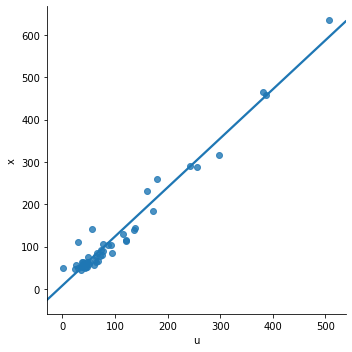

In [77]:
import seaborn as sns


sns.lmplot(x="u",y="x", data=bigcity_df, ci=None)

# Question 6 - Evaluation of model with scikit-learn 
Validate the model with Root Mean Squares error and R^2 score using scikit-learn. RMSE and R2 for test data and prediction

Hint: You can import mean_squared_error function & r2 (R square) from sklearn.metrics. Performing root operation over mean square error over mean square error gives you root mean square error

In [80]:
from sklearn import metrics

#predict y for xtest
y_pred = model.predict(X_test)

#mean squared error, lesser the better .Are called loss functions
mse = metrics.mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print("RMSE ",rmse)

#variance score captured by our model, 1 is perfect prediction
print("Test R2 score",metrics.r2_score(y_test,y_pred))

RMSE  20.821207849503107
Test R2 score 0.984648896095209


In [ ]:
# conclusion minimum the RMSE the better, 20 seems to be low value. however, we have checked on one model and 
# have nothing to compare against
#also R2 score indicates how far our model is capturing variance . Close to 1 indicates good model

## Question 7 - Calculate the accuracy of the model for both training and test data set 

### Hint: .score() function 

In [141]:
# Train accuracies
print("Train score accuracy is ",model.score(X_train, y_train))

Train score is  0.9467574390909765


In [81]:
# Test accuracies
print("Test score accuracy is ",model.score(X_test, y_test))

Test score accuracy is  0.9846488960952091


In [82]:
# conclusion: Model is performing equally well on both train and test data

# Supervised Learning - Building a Student Performace Prediction System


# Classification vs. Regression
The aim of this project is to predict how likely a student is to pass. Which type of supervised learning problem is this, classification or regression? Why?
Answer:
This project is a classification supervised learning problem because the variable to predict, i.e. if a student graduates or fails to graduate, is categorical. On this case this a dichotomous categorical variable where the only two possible values are "pass" or "fail".

### Overview:

1.Read the problem statement.

2.Get the dataset.

3.Explore the dataset.

4.Pre-processing of dataset.

5.Split data into train, test set.

6.Build Model.

7.Apply the model.

8.Evaluate the model.

9.Provide insights.

## Problem Statement 

Using Logistic Regression **predict the performance of student**. The classification goal is to predict whether the student will pass or fail.

## Dataset 

This data approach student achievement in secondary education of two Portuguese schools. The data attributes include student grades, demographic, social and school related features) and it was collected by using school reports and questionnaires. Two datasets are provided regarding the performance in Mathematics.

**Source:** https://archive.ics.uci.edu/ml/datasets/Student+Performance

# Question 1 - Exploring the Data 
*Read the dataset file using pandas. Take care about the delimiter.*

#### Answer:

In [117]:
student_df = pd.read_csv("students-data.csv", delimiter=';')
student_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
school        395 non-null object
sex           395 non-null object
age           395 non-null int64
address       395 non-null object
famsize       395 non-null object
Pstatus       395 non-null object
Medu          395 non-null int64
Fedu          395 non-null int64
Mjob          395 non-null object
Fjob          395 non-null object
reason        395 non-null object
guardian      395 non-null object
traveltime    395 non-null int64
studytime     395 non-null int64
failures      395 non-null int64
schoolsup     395 non-null object
famsup        395 non-null object
paid          395 non-null object
activities    395 non-null object
nursery       395 non-null object
higher        395 non-null object
internet      395 non-null object
romantic      395 non-null object
famrel        395 non-null int64
freetime      395 non-null int64
goout         395 non-null int64
Dalc          395 no

# Question 2 - Drop missing values 
*Set the index name of the dataframe to **"number"**. Check sample of data to drop if any missing values are there.*
*Use .dropna() function to drop the NAs*

#### Answer:

In [108]:
student_df.head(5)

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


In [145]:
student_df.index.name = 'number'
student_df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
number,,,,,,,,,,,,,,,,,,,,,
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


In [120]:
#printing missing value counts #DEBUG
print(student_df[student_df.isna()==True].count())

#loop through all the columns ,find ifthe column has any missing value. If it is there, drop the column
for feature in student_df.columns: # Loop through all columns in the dataframe
    if student_df[feature].isna == True: 
        student_df.dropna(axis=1, how="any", inplace=True)


school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
goout         0
Dalc          0
Walc          0
health        0
absences      0
G1            0
G2            0
G3            0
dtype: int64


In [110]:
#No NA so no dropping
student_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
school        395 non-null object
sex           395 non-null object
age           395 non-null int64
address       395 non-null object
famsize       395 non-null object
Pstatus       395 non-null object
Medu          395 non-null int64
Fedu          395 non-null int64
Mjob          395 non-null object
Fjob          395 non-null object
reason        395 non-null object
guardian      395 non-null object
traveltime    395 non-null int64
studytime     395 non-null int64
failures      395 non-null int64
schoolsup     395 non-null object
famsup        395 non-null object
paid          395 non-null object
activities    395 non-null object
nursery       395 non-null object
higher        395 non-null object
internet      395 non-null object
romantic      395 non-null object
famrel        395 non-null int64
freetime      395 non-null int64
goout         395 non-null int64
Dalc          395 no

In [111]:
student_df.describe()

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000
mean,16.696203,2.749367,2.521519,1.448101,2.035443,0.334177,3.944304,3.235443,3.108861,1.481013,2.291139,3.554430,5.708861,10.908861,10.713924,10.415190
std,1.276043,1.094735,1.088201,0.697505,0.839240,0.743651,0.896659,0.998862,1.113278,0.890741,1.287897,1.390303,8.003096,3.319195,3.761505,4.581443
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,3.000000,0.000000,0.000000
25%,16.000000,2.000000,2.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,3.000000,0.000000,8.000000,9.000000,8.000000
50%,17.000000,3.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,4.000000,11.000000,11.000000,11.000000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,8.000000,13.000000,13.000000,14.000000
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,75.000000,19.000000,19.000000,20.000000


#### Variables with less variance are almost same for all the records. Hence, they do not contribute much for classification.

# Question 3 - Encode all categorical variables to numerical 

Take the list of categorical attributes(from the above result) and convert them into neumerical variables. After that, print the head of dataframe and check the values.

**Hint:** check **sklearn LabelEncoder()**

#### Answer:

In [119]:
#print(student_df.dtypes)

In [123]:
from sklearn import preprocessing

label_encoder = preprocessing.LabelEncoder() 

for feature in student_df.columns: # Loop through all columns in the dataframe
    if student_df[feature].dtype == 'object': # Only apply for columns with categorical strings
        student_df[feature]= label_encoder.fit_transform(student_df[feature]) 
        
student_df.head()


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,0,0,18,1,0,0,4,4,0,4,...,4,3,4,1,1,3,6,5,6,6
1,0,0,17,1,0,1,1,1,0,2,...,5,3,3,1,1,3,4,5,5,6
2,0,0,15,1,1,1,1,1,0,2,...,4,3,2,2,3,3,10,7,8,10
3,0,0,15,1,0,1,4,2,1,3,...,3,2,2,1,1,5,2,15,14,15
4,0,0,16,1,0,1,3,3,2,2,...,4,3,2,1,2,5,4,6,10,10


In [ ]:
#categorical varaibles converted to 0, 1,2 so on

# Question 4 - Convert the continuous values of grades into classes 

*Consider the values in G1, G2 and G3 with >= 10 as pass(1) and < 10 as fail(0) and encode them into binary values. Print head of dataframe to check the values.*

#### Answer:

In [125]:
#Gardes are converted to binary classes 0(fail) and 1(pass)

student_df.G1 = np.where(student_df.G1 >=10, 1, 0)
student_df.G2 = np.where(student_df.G2 >=10, 1, 0)
student_df.G3 = np.where(student_df.G3 >=10, 1, 0)

student_df.head()


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,0,0,18,1,0,0,4,4,0,4,...,4,3,4,1,1,3,6,0,0,0
1,0,0,17,1,0,1,1,1,0,2,...,5,3,3,1,1,3,4,0,0,0
2,0,0,15,1,1,1,1,1,0,2,...,4,3,2,2,3,3,10,0,0,1
3,0,0,15,1,0,1,4,2,1,3,...,3,2,2,1,1,5,2,1,1,1
4,0,0,16,1,0,1,3,3,2,2,...,4,3,2,1,2,5,4,0,1,1


# Question 5 

*Consider G3 is the target attribute and remaining all attributes as features to predict G3. Now, separate features and target into separate dataframes and name them X and y respectively.*

Answer

In [126]:
#Features
X = student_df.drop("G3", axis=1)
#Targets
y = student_df[['G3']]

In [128]:
student_df.groupby(["G3"]).count()

# Most are pass. The ratio is almost 1:2 in favor or class 1.  The model's ability to predict class 1 (pass) will 
# be better than predicting class 0(fail. 

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,romantic,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2
G3,,,,,,,,,,,,,,,,,,,,,
0,130,130,130,130,130,130,130,130,130,130,...,130,130,130,130,130,130,130,130,130,130
1,265,265,265,265,265,265,265,265,265,265,...,265,265,265,265,265,265,265,265,265,265


## Visualization

## Question 6

*Plot G2 and G3 and give your understanding on relation between both variables.*

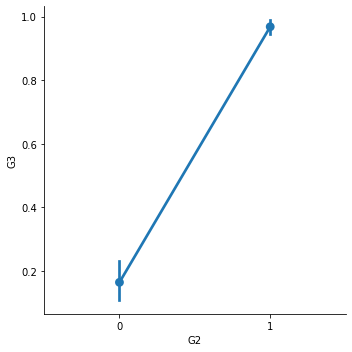

In [135]:
sns.catplot(x="G2", y="G3",kind="point", data=student_df);

In [153]:
#From the graph it is evident that There is strong correlation between G2 and G3
#verifying by calculating correlation coefficients as well

In [136]:
student_df[['G2','G3']].corr()

,G2,G3
G2,1.000000,0.825393
G3,0.825393,1.000000


## Question 7

*Plot the number of students in each school and number of students with different ages in separate plots.*

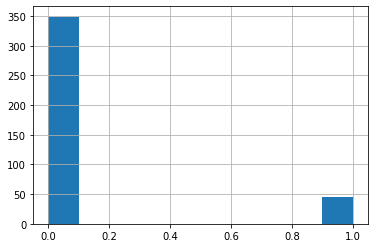

In [137]:
student_df['school'].hist()

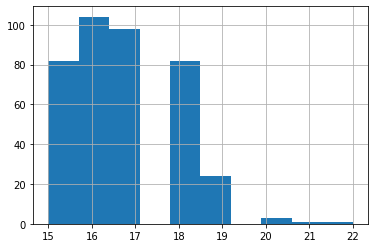

In [138]:
student_df['age'].hist(bins=10)

## Question 8 - Training and testing data split

 *So far, you have converted all categorical features into numeric values. Now, split the data into training and test sets with training size of 300 records. Print the number of train and test records.*

**Hint:** check **train_test_split()** from **sklearn**

#### Answer:

In [139]:
#Train and test split, train data roughly 300
test_size = 0.24 # taking 75:25 training and test set

X_train, X_test, y_train, y_test = train_test_split(X, y,test_size =test_size, random_state = 7)
print(X_train.shape)
print(X_test.shape)

(300, 32)
(95, 32)


## Question 9 - Model Implementation and Testing the Accuracy 

*Build a **LogisticRegression** classifier using **fit()** functions in sklearn. 
* You need to import both Logistic regression and accuracy score from sklearn*
#### Answer:

In [140]:
#1LOGISTIC REGRESSION
from sklearn.linear_model import LogisticRegression
# calculate accuracy measures and confusion matrix
from sklearn import metrics
from sklearn.metrics import accuracy_score, confusion_matrix, recall_score, precision_score, f1_score, auc, roc_curve

model = LogisticRegression()
model.fit(X_train, y_train)
print("Train accuracy score",model.score(X_train, y_train))
print("Test score",model.score(X_test, y_test))

#for creating confusion matrix
y_predict = model.predict(X_test)
print("\nConfusion Matrix \n",confusion_matrix(y_test,y_predict))

#predict probability of x train
y_predictProb = model.predict_proba(X_train)

fpr, tpr, thresholds = roc_curve(y_train, y_predictProb[::,1])


roc_auc = auc(fpr, tpr)
print("ROC_AUC",roc_auc)
optimalF1 = 0
optimalTh = 0
thresholds[0:10]

Train accuracy score 0.91
Test score 0.9473684210526315

Confusion Matrix 
 [[22  3]
 [ 2 68]]
ROC_AUC 0.9707448107448108


C:\Users\DELL\Anaconda3\lib\site-packages\sklearn\linear_model\logistic.py:432: FutureWarning: Default solver will be changed to 'lbfgs' in 0.22. Specify a solver to silence this warning.
  FutureWarning)
C:\Users\DELL\Anaconda3\lib\site-packages\sklearn\utils\validation.py:724: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


array([1.99715771, 0.99715771, 0.9335081 , 0.93069124, 0.88708364,
       0.88671104, 0.86652515, 0.85956917, 0.74560251, 0.71652786])

In [144]:
for th in thresholds:
    preds = np.where(model.predict_proba(X_train)[:,1] > th, 1, 0)
    f1Score = f1_score(y_train, preds)
    if(optimalF1 < f1Score):
        optimalF1 = f1Score
        optimalTh = th
        
        #Non optimal th
preds = np.where(model.predict_proba(X_test)[:,1] > 0.5, 1, 0)
print("0.5 threshold\n",pd.DataFrame(data=[accuracy_score(y_test, preds), 
                   recall_score(y_test, preds), 
                   precision_score(y_test, preds),
                   f1_score(y_test, preds)], 
             index=["accuracy", "recall", "precision", "f1_score"]))
#optimal th
preds = np.where(model.predict_proba(X_test)[:,1] > optimalTh, 1, 0)
print("\n\noptimal threshold",optimalTh)
print(pd.DataFrame(data=[accuracy_score(y_test, preds), 
                   recall_score(y_test, preds), 
                   precision_score(y_test, preds),
                   f1_score(y_test, preds)], 
             index=["accuracy", "recall", "precision", "f1_score"]))

C:\Users\DELL\Anaconda3\lib\site-packages\sklearn\metrics\classification.py:1437: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 due to no predicted samples.
  'precision', 'predicted', average, warn_for)
C:\Users\DELL\Anaconda3\lib\site-packages\sklearn\metrics\classification.py:1437: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 due to no predicted samples.
  'precision', 'predicted', average, warn_for)


0.5 threshold
                   0
accuracy   0.947368
recall     0.971429
precision  0.957746
f1_score   0.964539


optimal threshold 0.46286776022183895
                  0
accuracy   0.947368
recall     0.971429
precision  0.957746
f1_score   0.964539


In [145]:
#conclusion Model is good fit and optimal threhold is quite close to deault threhold of 0.5. performance on train and testing
#data iis similar